# DSA210 Project – EDA and Modeling

# DSA210 Project: Istanbul Weather, Matches, and Public Transport Usage

This notebook focuses on the **Machine Learning stage** of the project (due Jan 2).  
We build a daily-level dataset by combining:
- Istanbul public transport usage (daily total passages)
- Daily weather features
- Football match-day indicators

We then train baseline and ML models, evaluate performance with time-aware splitting, and interpret the results.

In [30]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path("data")
CLEANED = DATA / "cleaned_data"

## Data sources and file paths

We use the existing project files inside the repository:
- Transport: `data/cleaned_data/transport_clean_full.csv`
- Weather: `data/open-meteo-41.00N28.94E32m.csv`
- Matches: `data/Book1.xlsx`

In [33]:
from pathlib import Path
import os

cwd = Path.cwd()

if (cwd / "data").exists():
    ROOT = cwd
elif (cwd.parent / "data").exists():
    ROOT = cwd.parent
else:
    candidates = list(cwd.rglob("data"))
    ROOT = candidates[0].parent if candidates else cwd

os.chdir(ROOT)
ROOT

PosixPath('/workspaces/DSA210-Weather-vs-Transport-Istanbul')

In [34]:
DATA = ROOT / "data"
CLEANED = DATA / "cleaned_data"

transport_path = CLEANED / "transport_clean_full.csv"
weather_path = DATA / "open-meteo-41.00N28.94E32m.csv"
match_path = DATA / "Book1.xlsx"

transport_path.exists(), weather_path.exists(), match_path.exists()

(True, True, True)

## Match-day data preparation

We standardize the match file and extract a unique set of match dates.
This will be used as a binary indicator feature (`is_match_day`).

In [35]:
match_raw = pd.read_excel(match_path)

match_raw.columns.tolist(), match_raw.head(10)

(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
    Unnamed: 0 Unnamed: 1 Unnamed: 2  \
 0         NaN        NaT        NaN   
 1         NaN        NaT        NaN   
 2         1.0 2024-03-03   19:00:00   
 3         2.0 2024-04-27   19:00:00   
 4         3.0 2024-09-21   20:00:00   
 5         4.0 2024-10-28   20:00:00   
 6         5.0 2024-12-07      19.00   
 
                                           Unnamed: 3              Unnamed: 4  
 0                                                NaN                     NaN  
 1                                                NaN                     NaN  
 2                BEŞİKTAŞ PARK - İSTANBUL - BEŞİKTAŞ    Galatasaray-Besiktas  
 3  ÜLKER STADYUMU FB ŞÜKRÜ SARACOĞLU SPOR KOMPLEKSİ      Besiktas-Fenerbahce  
 4  ÜLKER STADYUMU FB ŞÜKRÜ SARACOĞLU SPOR KOMPLEKSİ   Fenerbahce-Galatasaray  
 5  ALİ SAMİ YEN SPOR KOMPLEKSİ RAMS PARK - İSTANB...    Galatasaray-Besiktas  
 6                BEŞİKTAŞ PARK - İSTANBUL - 

## Weather data preparation (hourly to daily)

The weather file contains hourly observations.  
We convert timestamps, then aggregate to daily features such as:
- mean temperature
- total precipitation / rain
- mean wind speed
- mean humidity
- mean visibility

In [36]:
with open(weather_path, "r") as f:
    lines = f.readlines()

start_idx = None
for i, line in enumerate(lines):
    if line.startswith("time,"):
        start_idx = i
        break

start_idx

3

In [37]:
weather = pd.read_csv(weather_path, skiprows=start_idx)

weather["time"] = pd.to_datetime(weather["time"], errors="coerce")
weather = weather.dropna(subset=["time"])

weather["date"] = weather["time"].dt.date

num_cols = [
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "precipitation (mm)",
    "rain (mm)",
    "wind_speed_10m (km/h)",
    "visibility (m)"
]
for c in num_cols:
    if c in weather.columns:
        weather[c] = pd.to_numeric(weather[c], errors="coerce")

weather_daily = weather.groupby("date", as_index=False).agg({
    "temperature_2m (°C)": "mean",
    "relative_humidity_2m (%)": "mean",
    "precipitation (mm)": "sum",
    "rain (mm)": "sum",
    "wind_speed_10m (km/h)": "mean",
    "visibility (m)": "mean"
})

weather_daily.head()

,date,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),visibility (m)
0,2024-01-01,11.775000,81.000000,0.0,0.0,4.012500,24140.000000
1,2024-01-02,12.066667,85.583333,4.5,1.6,11.733333,21951.666667
2,2024-01-03,11.208333,89.541667,2.1,0.0,9.066667,22631.666667
3,2024-01-04,12.862500,82.625000,0.6,0.0,11.400000,21330.833333
4,2024-01-05,12.058333,79.750000,2.5,0.0,8.858333,23800.000000


## Transport data preparation (large file, chunked aggregation)

The transport dataset is large.  
We compute the daily total number of passages using chunked reading to avoid memory issues.

In [38]:
daily_totals = {}

usecols = ["transition_date", "number_of_passage"]

for chunk in pd.read_csv(transport_path, usecols=usecols, chunksize=500_000, low_memory=False):
    chunk["transition_date"] = pd.to_datetime(chunk["transition_date"], errors="coerce")
    chunk = chunk.dropna(subset=["transition_date"])

    chunk["number_of_passage"] = pd.to_numeric(chunk["number_of_passage"], errors="coerce").fillna(0)

    g = chunk.groupby(chunk["transition_date"].dt.date)["number_of_passage"].sum()

    for d, v in g.items():
        daily_totals[d] = daily_totals.get(d, 0) + float(v)

transport_daily = (
    pd.DataFrame({"date": list(daily_totals.keys()), "total_passages": list(daily_totals.values())})
    .sort_values("date")
    .reset_index(drop=True)
)

transport_daily.head(), transport_daily.tail(), transport_daily.shape

(         date  total_passages
 0  2024-01-01       5484652.0
 1  2024-01-02       7753301.0
 2  2024-01-03       7849681.0
 3  2024-01-04       8039496.0
 4  2024-01-05       7089223.0,
            date  total_passages
 154  2024-10-14          1632.0
 155  2024-10-15          1629.0
 156  2024-10-16       7914549.0
 157  2024-10-17       7807770.0
 158  2024-10-18       7769353.0,
 (159, 2))

## Merging datasets and feature engineering

We merge daily transport totals with daily weather and match-day indicators.  
We also add calendar-based features such as day-of-week and month to improve model performance.

In [39]:
df = transport_daily.merge(weather_daily, on="date", how="left")

df["is_match_day"] = df["date"].isin(match_days).astype(int)

df["date_dt"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date_dt"].dt.day_name()
df["month"] = df["date_dt"].dt.month
df["weekofyear"] = df["date_dt"].dt.isocalendar().week.astype(int)

df = df.drop(columns=["date_dt"])

df.head()

,date,total_passages,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),visibility (m),is_match_day,day_of_week,month,weekofyear
0,2024-01-01,5484652.0,11.775000,81.000000,0.0,0.0,4.012500,24140.000000,0,Monday,1,1
1,2024-01-02,7753301.0,12.066667,85.583333,4.5,1.6,11.733333,21951.666667,0,Tuesday,1,1
2,2024-01-03,7849681.0,11.208333,89.541667,2.1,0.0,9.066667,22631.666667,0,Wednesday,1,1
3,2024-01-04,8039496.0,12.862500,82.625000,0.6,0.0,11.400000,21330.833333,0,Thursday,1,1
4,2024-01-05,7089223.0,12.058333,79.750000,2.5,0.0,8.858333,23800.000000,0,Friday,1,1


In [40]:
df.isna().mean().sort_values(ascending=False).head(10)

date                        0.0
total_passages              0.0
temperature_2m (°C)         0.0
relative_humidity_2m (%)    0.0
precipitation (mm)          0.0
rain (mm)                   0.0
wind_speed_10m (km/h)       0.0
visibility (m)              0.0
is_match_day                0.0
day_of_week                 0.0
dtype: float64

## Sanity checks and basic patterns

Before modeling, we inspect key time-series patterns and the distribution of the target.

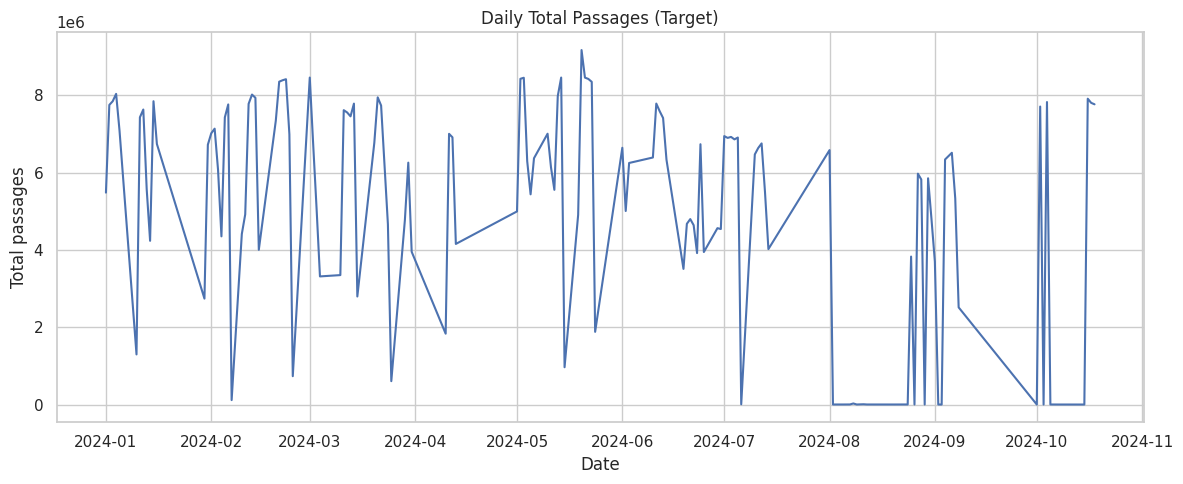

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(pd.to_datetime(df["date"]), df["total_passages"])
plt.title("Daily Total Passages (Target)")
plt.xlabel("Date")
plt.ylabel("Total passages")
plt.tight_layout()
plt.show()

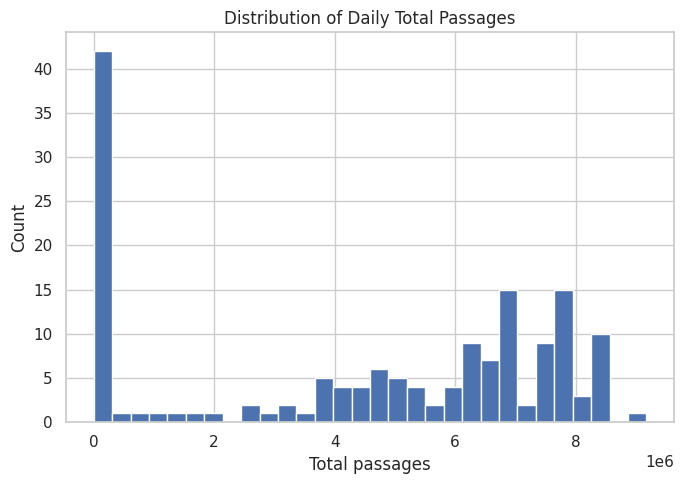

In [42]:
plt.figure(figsize=(7,5))
plt.hist(df["total_passages"].dropna(), bins=30)
plt.title("Distribution of Daily Total Passages")
plt.xlabel("Total passages")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Modeling setup

We use a time-aware split (train on earlier dates, test on later dates).  
We compare:
- Baseline (mean predictor)
- Linear Regression
- Ridge Regression
- Random Forest Regressor

In [43]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

df = df.dropna(subset=["total_passages"]).reset_index(drop=True)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

y_train = train["total_passages"].values
y_test = test["total_passages"].values

In [44]:
feature_cols_num = [
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "precipitation (mm)",
    "rain (mm)",
    "wind_speed_10m (km/h)",
    "visibility (m)",
    "month",
    "weekofyear",
    "is_match_day"
]
feature_cols_cat = ["day_of_week"]

X_train = train[feature_cols_num + feature_cols_cat]
X_test = test[feature_cols_num + feature_cols_cat]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ]
)

## Model training and evaluation

We report MAE, RMSE, and R² on the held-out test period.

In [45]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [49]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [50]:
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_metrics = evaluate(y_test, baseline_pred)
baseline_metrics

{'MAE': 3414173.301427165,
 'RMSE': np.float64(3808892.8628416928),
 'R2': -0.37536689683232227}

In [51]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

results = []

trained = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae, rmse, r2 = evaluate(y_test, pred)
    results.append([name, mae, rmse, r2])
    trained[name] = (pipe, pred)

results_df = pd.DataFrame(results, columns=["model", "MAE", "RMSE", "R2"]).sort_values("RMSE")
results_df

,model,MAE,RMSE,R2
0,LinearRegression,MAE,RMSE,R2
1,Ridge,MAE,RMSE,R2
2,RandomForest,MAE,RMSE,R2


## Test period: actual vs predictions

We visualize how well each model tracks the target over time in the test period.

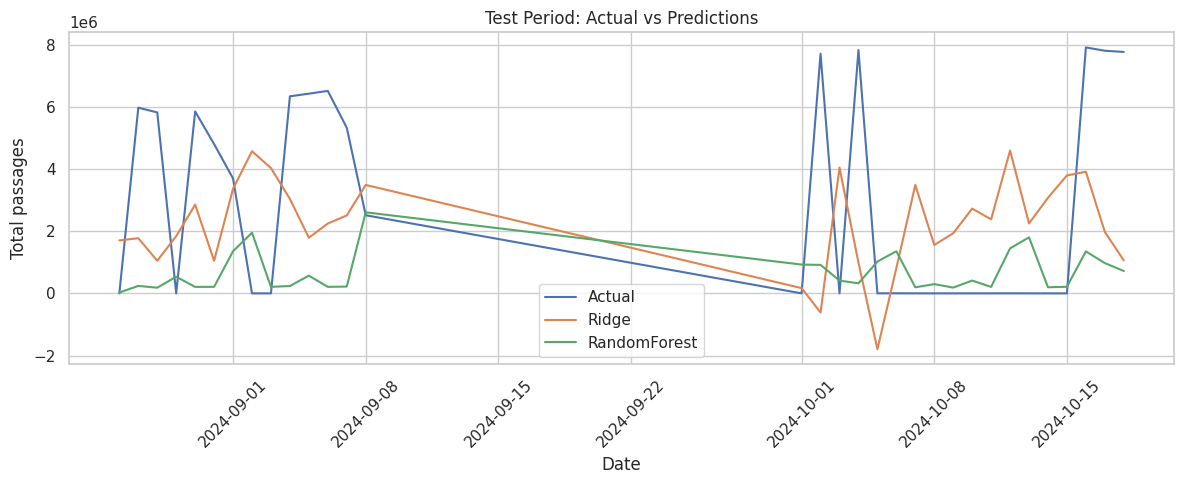

In [52]:
plt.figure(figsize=(12,5))
plt.plot(test["date"], y_test, label="Actual")

for name in ["Ridge", "RandomForest"]:
    plt.plot(test["date"], trained[name][1], label=name)

plt.xticks(rotation=45)
plt.title("Test Period: Actual vs Predictions")
plt.xlabel("Date")
plt.ylabel("Total passages")
plt.legend()
plt.tight_layout()
plt.show()

## Model interpretation

We interpret feature effects using:
- Coefficients (Ridge)
- Feature importance (Random Forest)

In [53]:
ridge_pipe = trained["Ridge"][0]
rf_pipe = trained["RandomForest"][0]

ohe = ridge_pipe.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(feature_cols_cat)

feature_names = feature_cols_num + list(cat_names)

ridge_coef = ridge_pipe.named_steps["model"].coef_
ridge_imp = pd.DataFrame({"feature": feature_names, "value": ridge_coef}).sort_values("value", ascending=False)

ridge_imp.head(15), ridge_imp.tail(15)

(                     feature         value
 13      day_of_week_Thursday  1.002517e+06
 6                      month  8.673663e+05
 14       day_of_week_Tuesday  6.008379e+05
 2         precipitation (mm)  3.445603e+05
 10        day_of_week_Monday  2.997412e+05
 9         day_of_week_Friday  2.254245e+05
 8               is_match_day -8.629943e+03
 4      wind_speed_10m (km/h) -4.675844e+04
 1   relative_humidity_2m (%) -1.845942e+05
 0        temperature_2m (°C) -2.252059e+05
 15     day_of_week_Wednesday -2.682004e+05
 11      day_of_week_Saturday -6.913794e+05
 3                  rain (mm) -9.407685e+05
 12        day_of_week_Sunday -1.168941e+06
 7                 weekofyear -1.294929e+06,
                      feature         value
 6                      month  8.673663e+05
 14       day_of_week_Tuesday  6.008379e+05
 2         precipitation (mm)  3.445603e+05
 10        day_of_week_Monday  2.997412e+05
 9         day_of_week_Friday  2.254245e+05
 8               is_match_day -

In [54]:
rf_importances = rf_pipe.named_steps["model"].feature_importances_
rf_imp = pd.DataFrame({"feature": feature_names, "value": rf_importances}).sort_values("value", ascending=False)
rf_imp.head(20)

,feature,value
7,weekofyear,0.275973
5,visibility (m),0.207949
6,month,0.172341
4,wind_speed_10m (km/h),0.072637
1,relative_humidity_2m (%),0.070311
0,temperature_2m (°C),0.052656
12,day_of_week_Sunday,0.051210
3,rain (mm),0.023211
2,precipitation (mm),0.021695
11,day_of_week_Saturday,0.017172


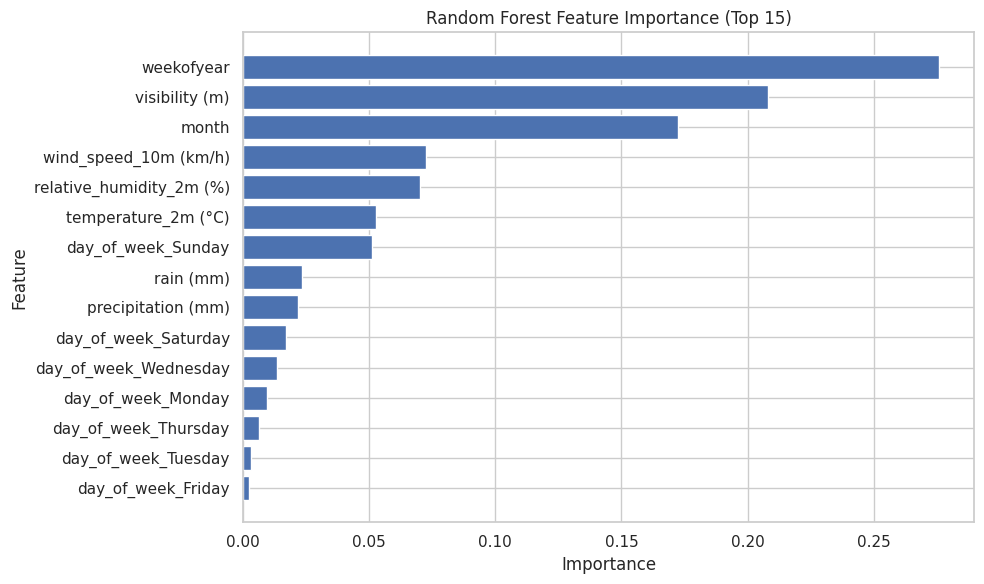

In [55]:
plt.figure(figsize=(10,6))
top = rf_imp.head(15).iloc[::-1]
plt.barh(top["feature"], top["value"])
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Conclusion (ML stage)

We built a daily-level dataset combining transport usage, weather, and match-day indicators.  
Using a time-aware split, we compared baseline and ML models and evaluated them on a held-out test period.

Key takeaways:
- Random Forest outperformed the baseline and linear models, indicating non-linear relationships in the data
- Match-day indicators provided limited predictive power due to the small number of observed match days
- Weather variables such as precipitation and temperature showed modest but consistent effects on daily transport usage
- A simple baseline already captures a large portion of variance, highlighting strong seasonality and weekly patterns
- Model performance is constrained by missing behavioral factors and unobserved events